## LLM deviner les etiquettes 

### 1. Importation et nettoyage des données 

1.1 Importation et construction de la datframe de travail 

In [1]:
import pandas as pd
import numpy as np

In [15]:
#IMPORTATION DES DONNÉES
df_logement = pd.read_parquet(r'C:/Users/marvi/Documents/COURS_SISE/4_Python_ML/Projet_maj/Projet_ENEDIS/ml_project\data\df_logements.parquet')


In [16]:
df_logement.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 30 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   conso_5_usages_ef                  250000 non-null  float64 
 1   conso_5_usages_ef_energie_n1       250000 non-null  float64 
 2   code_departement_ban               249760 non-null  float32 
 3   adresse_brut                       249995 non-null  category
 4   code_region_ban                    249760 non-null  float32 
 5   cout_total_5_usages                250000 non-null  float64 
 6   hauteur_sous_plafond               250000 non-null  float32 
 7   nom_commune_ban                    250000 non-null  category
 8   coordonnee_cartographique_x_ban    250000 non-null  float64 
 9   qualite_isolation_murs             250000 non-null  category
 10  type_batiment                      250000 non-null  category
 11  periode_construction      

In [17]:
colonnes_adresse = [
    'adresse_brut',
    'adresse_ban',
    'nom_commune_ban',
    'code_postal_ban',
    'code_departement_ban',
    'code_region_ban',
    'nom_rue_ban',
    'coordonnee_cartographique_x_ban',
    'coordonnee_cartographique_y_ban',
    'latitude',
    'longitude'
]

In [18]:
df_logement.columns.tolist()

['conso_5_usages_ef',
 'conso_5_usages_ef_energie_n1',
 'code_departement_ban',
 'adresse_brut',
 'code_region_ban',
 'cout_total_5_usages',
 'hauteur_sous_plafond',
 'nom_commune_ban',
 'coordonnee_cartographique_x_ban',
 'qualite_isolation_murs',
 'type_batiment',
 'periode_construction',
 'type_energie_principale_chauffage',
 'date_reception_dpe',
 'cout_total_5_usages_energie_n1',
 'adresse_ban',
 'coordonnee_cartographique_y_ban',
 'type_energie_n1',
 'code_postal_ban',
 'surface_habitable_logement',
 'etiquette_dpe',
 '_score',
 'code_postal_source',
 'annee_recherche',
 'date_extraction',
 'nom_rue_ban',
 'nombre_appartement',
 'latitude',
 'longitude',
 'logement']

-  Variable à prédire (Cible) (Y) -> etiquette_dpe (object)
-  Variables prédictives (X)      -> 'conso_5_usages_ef', 'conso_5_usages_ef_energie_n1', 'cout_total_5_usages', 'hauteur_sous_plafond','qualite_isolation_murs', 'type_batiment', 'type_energie_principale_chauffage', 'cout_total_5_usages_energie_n1', 'type_energie_n1', 'surface_habitable_logement', 'logement', 'nombre_appartement'

In [19]:
Variable_Etiquette = ['conso_5_usages_ef',
 'conso_5_usages_ef_energie_n1',
 'cout_total_5_usages',
 'hauteur_sous_plafond',
 'qualite_isolation_murs',
 'type_batiment',
 'type_energie_principale_chauffage',
 'cout_total_5_usages_energie_n1',
 'type_energie_n1',
 'surface_habitable_logement',
 'etiquette_dpe',
 'nombre_appartement',
 'logement', 
 'periode_construction',
 'latitude',
 'longitude']

In [20]:
df_Variables = df_logement[Variable_Etiquette]

In [21]:
df_Variables.head()

,conso_5_usages_ef,conso_5_usages_ef_energie_n1,cout_total_5_usages,hauteur_sous_plafond,qualite_isolation_murs,type_batiment,type_energie_principale_chauffage,cout_total_5_usages_energie_n1,type_energie_n1,surface_habitable_logement,etiquette_dpe,nombre_appartement,logement,periode_construction,latitude,longitude
0,3644.6,3644.6,848.0,3.4,insuffisante,appartement,Électricité,848.0,Électricité,29.299999,E,NaN,ancien,avant 1948,45.754486,4.830387
1,6066.9,6066.9,1048.0,2.5,bonne,appartement,Électricité,1048.0,Électricité,60.000000,D,NaN,ancien,2006-2012,45.641712,4.683915
2,5947.4,5716.3,589.4,2.6,insuffisante,appartement,Gaz naturel,532.6,Gaz naturel,36.000000,D,1.0,ancien,1948-1974,45.778416,4.820675
3,14767.1,14486.4,1653.9,2.5,insuffisante,appartement,Gaz naturel,1556.5,Gaz naturel,50.000000,E,1.0,ancien,1948-1974,45.691036,4.935695
4,14219.1,11864.8,1422.8,2.5,insuffisante,appartement,Réseau de chauffage urbain,933.8,Réseau de chauffage urbain,58.000000,E,152.0,ancien,1948-1974,45.749638,4.903878


In [22]:
df_Variables.shape

(250000, 16)

1.2 Valeur Manquantes

In [24]:
#Valeur manquante dans chaque colonne (en pourcentage) (si 0 ne pas afficher) (vm = valeur manquante)
vm_percentage = df_Variables.isnull().mean() * 100
vm_percentage = vm_percentage[vm_percentage > 0]
print(vm_percentage)

nombre_appartement    6.3876
dtype: float64


In [25]:
df_Variables['nombre_appartement']

0           NaN
1           NaN
2           1.0
3           1.0
4         152.0
          ...  
249995      1.0
249996      NaN
249997      1.0
249998      1.0
249999      1.0
Name: nombre_appartement, Length: 250000, dtype: float32

In [26]:
# Hypothèse numéro 1 : Type de logement 
df_Variables['type_batiment']

missing_surface = df_Variables[
    (df_Variables['type_batiment'] == 'maison') &
    (df_Variables['nombre_appartement'].isnull())
]
print(missing_surface.shape[0])

#Alors metre 1 (car maison )


940


In [27]:
df_Variables.loc[
    (df_Variables['type_batiment'] == 'maison') &
    (df_Variables['nombre_appartement'].isnull()),
    'nombre_appartement'
] = 1.0

In [28]:
df_Variables['nombre_appartement'].isnull().sum()

np.int64(15029)

In [29]:
df_Variables = df_Variables.dropna(subset=['nombre_appartement'])

In [30]:
df_Variables['nombre_appartement'].describe()

count    234971.000000
mean         24.755075
std          46.723557
min           1.000000
25%           1.000000
50%           1.000000
75%          30.000000
max        5000.000000
Name: nombre_appartement, dtype: float64

In [31]:
seuil_99 = df_Variables['nombre_appartement'].quantile(0.99)

In [32]:
df_Variables['nombre_appartement'] = np.clip(
    df_Variables['nombre_appartement'],
    a_min=None,
    a_max=seuil_99
)

In [33]:
bins = [1, 4, 10, 31, np.inf]
labels = [
    'Maison(Unitaire ou 2 à 3 logements)', 
    'Petit Collectif(4 à 9 logements)', 
    'Moyen Collectif(10 à 30 logements)', 
    'Grand Collectif(> 30 logements)'
]

# Application de la discrétisation
df_Variables['nombre_appartement_cat'] = pd.cut(
    df_Variables['nombre_appartement'],
    bins=bins,
    labels=labels,
    right=False,        # La borne supérieure est exclusive (e.g., [1, 2) contient 1)
    include_lowest=True # Inclut la borne la plus basse (1)
).astype('category')

In [34]:
df_Variables['nombre_appartement_cat'].value_counts()

nombre_appartement_cat
Maison(Unitaire ou 2 à 3 logements)    121228
Grand Collectif(> 30 logements)         57808
Moyen Collectif(10 à 30 logements)      48568
Petit Collectif(4 à 9 logements)         7367
Name: count, dtype: int64

In [35]:
df_Variables = df_Variables.drop(columns=['nombre_appartement'])

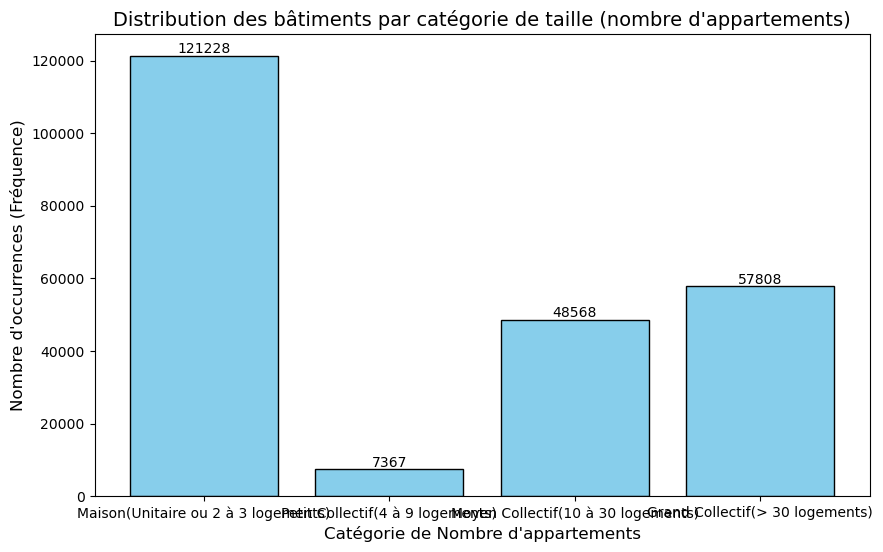

In [36]:
import matplotlib.pyplot as plt


counts = df_Variables['nombre_appartement_cat'].value_counts()
counts = counts.sort_index()
categories = counts.index.to_list()
values = counts.values.tolist()


plt.figure(figsize=(10, 6))
plt.bar(categories, values, color='skyblue', edgecolor='black')
plt.title("Distribution des bâtiments par catégorie de taille (nombre d'appartements)", fontsize=14)
plt.xlabel("Catégorie de Nombre d'appartements", fontsize=12)
plt.ylabel("Nombre d'occurrences (Fréquence)", fontsize=12)
for i, v in enumerate(values):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom')

plt.show()

1.3 Variable qualitative 

In [37]:
qualitatives = df_Variables.select_dtypes(include=['object', 'category']).columns.tolist() 
qualitatives

['qualite_isolation_murs',
 'type_batiment',
 'type_energie_principale_chauffage',
 'type_energie_n1',
 'etiquette_dpe',
 'logement',
 'periode_construction',
 'nombre_appartement_cat']

In [38]:
df_Variables['type_energie_n1'].value_counts()

type_energie_n1
Gaz naturel                   117050
Électricité                    72042
Réseau de chauffage urbain     42663
Bois et biomasse                1538
Fioul                           1343
Gaz (GPL/Propane/Butane)         328
Charbon                            7
Name: count, dtype: int64

1.3.1 Encodage Ordinal (avec un ordre logique)

In [39]:
df_Variables['qualite_isolation_murs'].value_counts()

qualite_isolation_murs
insuffisante    113123
très bonne       51077
bonne            47272
moyenne          23499
Name: count, dtype: int64

In [40]:
df_Variables['nombre_appartement_cat'].value_counts()

nombre_appartement_cat
Maison(Unitaire ou 2 à 3 logements)    121228
Grand Collectif(> 30 logements)         57808
Moyen Collectif(10 à 30 logements)      48568
Petit Collectif(4 à 9 logements)         7367
Name: count, dtype: int64

In [41]:
df_Variables['periode_construction'].value_counts()

periode_construction
1948-1974     73289
avant 1948    51740
après 2021    34418
2006-2012     17305
2013-2021     16903
1989-2000     14700
1975-1977      9284
1983-1988      6790
1978-1982      5704
2001-2005      4838
Name: count, dtype: int64

In [42]:
from sklearn.preprocessing import OrdinalEncoder

# Définition des ordres pour les variables ordinales
ordres_categories = {
    'qualite_isolation_murs': ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
    'etiquette_dpe': ['G', 'F', 'E', 'D', 'C', 'B', 'A'],
    'nombre_appartement_cat': [
    'Maison(Unitaire ou 2 à 3 logements)',
    'Petit Collectif(4 à 9 logements)',
    'Moyen Collectif(10 à 30 logements)',
    'Grand Collectif(> 30 logements)'], 
    'periode_construction': [
    'avant 1948', 
    '1948-1974',
    '1975-1977',
    '1978-1982',
    '1983-1988',
    '1989-2000',
    '2001-2005',
    '2006-2012',
    '2013-2021',
    'après 2021']
}

# Application de l'encodage ordinal
variables_ordinales = ['qualite_isolation_murs', 'etiquette_dpe', 'nombre_appartement_cat','periode_construction']

for col in variables_ordinales:
    df_Variables[col] = df_Variables[col].map({val: idx for idx, val in enumerate(ordres_categories[col])})

1.3.2 Encodage pour variables nominales

In [43]:
df_logement["type_batiment"].value_counts()

type_batiment
appartement    240088
immeuble         5579
maison           4333
Name: count, dtype: int64

In [44]:
df_logement['type_batiment'] = df_logement['type_batiment'].replace({'immeuble': 'appartement'})

C:\Users\marvi\AppData\Local\Temp\ipykernel_10220\1661861462.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_logement['type_batiment'] = df_logement['type_batiment'].replace({'immeuble': 'appartement'})


In [45]:
df_logement["type_batiment"].value_counts()

type_batiment
appartement    245667
maison           4333
Name: count, dtype: int64

In [46]:
df_logement.drop(columns=['type_batiment'], inplace=True)

In [47]:
# Variables nominales 
variables_nominales = [
    'type_energie_principale_chauffage', 
    'type_energie_n1',
    'logement'
]

# One-Hot Encoding avec pandas
df_Variables = pd.get_dummies(
    df_Variables, 
    columns=variables_nominales, 
    prefix=variables_nominales,
    drop_first=False
)

'qualite_isolation_murs'['très bonne','bonne','moyenne','insuffisante']
 'type_batiment'['appartement', 'immeuble', 'maison']
 'type_energie_principale_chauffage'['Gaz naturel', 'Electricite', 'Réseau de chauffage urbain', 'Bois et biomasse','Fioul','Gaz (GPL/Propane/Butane)','Charbon']
 'type_energie_n1' (enlever)
 'etiquette_dpe'['A','B','C','D','E','F','G']
 'logement'['neuf','ancien']
 'nombre_appartement_cat'['Maison(Unitaire ou 2 à 3 logements) ','Petit Collectif(4 à 9 logements)','Moyen Collectif(10 à 30 logements)','Grand Collectif(> 30 logements)']

In [48]:
df_Variables.head()

,conso_5_usages_ef,conso_5_usages_ef_energie_n1,cout_total_5_usages,hauteur_sous_plafond,qualite_isolation_murs,type_batiment,cout_total_5_usages_energie_n1,surface_habitable_logement,etiquette_dpe,periode_construction,...,type_energie_principale_chauffage_Électricité,type_energie_n1_Bois et biomasse,type_energie_n1_Charbon,type_energie_n1_Fioul,type_energie_n1_Gaz (GPL/Propane/Butane),type_energie_n1_Gaz naturel,type_energie_n1_Réseau de chauffage urbain,type_energie_n1_Électricité,logement_ancien,logement_neuf
2,5947.4,5716.3,589.4,2.6,0,appartement,532.6,36.000000,3,1,...,False,False,False,False,False,True,False,False,True,False
3,14767.1,14486.4,1653.9,2.5,0,appartement,1556.5,50.000000,2,1,...,False,False,False,False,False,True,False,False,True,False
4,14219.1,11864.8,1422.8,2.5,0,appartement,933.8,58.000000,2,1,...,False,False,False,False,False,False,True,False,True,False
5,12721.7,12061.9,1555.5,2.5,0,appartement,1326.4,48.900002,2,0,...,False,False,False,False,False,True,False,False,True,False
6,3058.9,3058.9,737.6,2.5,3,appartement,737.6,67.000000,5,0,...,True,False,False,False,False,False,False,True,True,False


1.4 Variable Quantitative

In [49]:
Quantitatives = df_Variables.select_dtypes(include=['int64', 'float64']).columns.tolist()
variables_exclure = ['qualite_isolation_murs', 'etiquette_dpe', 'nombre_appartement_cat']

variables_quantitatives = [col for col in Quantitatives if col not in variables_exclure]

print("Variables quantitatives pures:")
print(variables_quantitatives)

Variables quantitatives pures:
['conso_5_usages_ef', 'conso_5_usages_ef_energie_n1', 'cout_total_5_usages', 'cout_total_5_usages_energie_n1']


Statistiques des variables quantitatives:
       conso_5_usages_ef  conso_5_usages_ef_energie_n1  cout_total_5_usages  \
count       2.349710e+05                  2.349710e+05        234971.000000   
mean        1.374158e+04                  1.278899e+04          1523.842682   
std         5.338267e+04                  5.025450e+04          5400.448729   
min         1.320000e+02                  1.000000e+00            38.300000   
25%         4.362350e+03                  4.060850e+03           592.400000   
50%         7.044200e+03                  6.465700e+03           877.000000   
75%         1.164165e+04                  1.057750e+04          1259.500000   
max         3.686635e+06                  3.312323e+06        375061.300000   

       cout_total_5_usages_energie_n1  
count                   234971.000000  
mean                      1282.458813  
std                       4413.964542  
min                          0.000000  
25%                        486.100000  
50%   

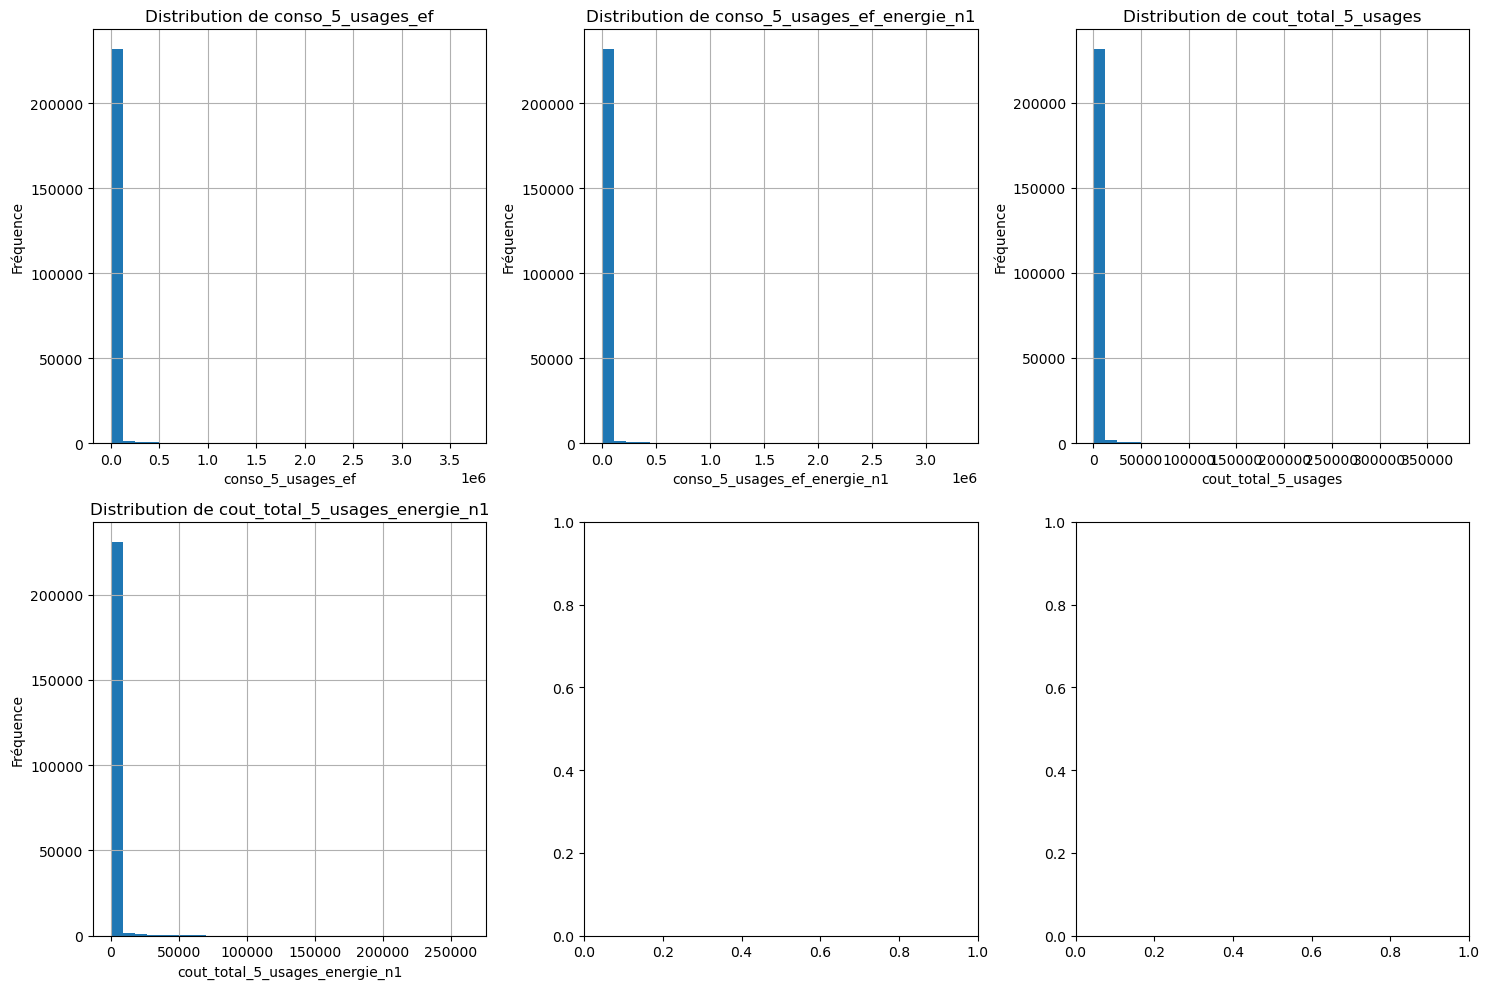

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Statistiques descriptives
print("Statistiques des variables quantitatives:")
print(df_Variables[variables_quantitatives].describe())

# Visualisation des distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(variables_quantitatives[:6]):  # Premières 6 variables
    df_Variables[col].hist(bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

In [52]:
#Ce qui pourrais etre reel (enlever les valeurs aberantes)
seuils = {
        'hauteur_sous_plafond': (1.8, 4.0),
        'surface_habitable_logement': (15, 300),
        'conso_5_usages_ef': (500, 50_000),
        'conso_5_usages_ef_energie_n1': (500, 50_000),
        'cout_total_5_usages': (100, 20_000),
        'cout_total_5_usages_energie_n1': (100, 20_000)
    }
# Appliquer les seuils une colonne à la fois
for col, (min_val, max_val) in seuils.items():
    if col in df_Variables.columns:
        # Créer le masque pour CETTE colonne
        masque = (df_Variables[col] >= min_val) & (df_Variables[col] <= max_val)
        # Appliquer le masque sur tout le DataFrame
        df_Variables = df_Variables[masque]

print(f" Nettoyage terminé. Shape final: {df_Variables.shape}")



 Nettoyage terminé. Shape final: (226247, 29)


In [53]:
df_Variables.head(1)

,conso_5_usages_ef,conso_5_usages_ef_energie_n1,cout_total_5_usages,hauteur_sous_plafond,qualite_isolation_murs,type_batiment,cout_total_5_usages_energie_n1,surface_habitable_logement,etiquette_dpe,periode_construction,...,type_energie_principale_chauffage_Électricité,type_energie_n1_Bois et biomasse,type_energie_n1_Charbon,type_energie_n1_Fioul,type_energie_n1_Gaz (GPL/Propane/Butane),type_energie_n1_Gaz naturel,type_energie_n1_Réseau de chauffage urbain,type_energie_n1_Électricité,logement_ancien,logement_neuf
2,5947.4,5716.3,589.4,2.6,0,appartement,532.6,36.0,3,1,...,False,False,False,False,False,True,False,False,True,False


Statistiques des variables quantitatives:
       conso_5_usages_ef  conso_5_usages_ef_energie_n1  cout_total_5_usages  \
count      226247.000000                 226247.000000        226247.000000   
mean         8606.237452                   7966.595488           977.732631   
std          5957.154816                   5590.770147           573.581798   
min           580.000000                    519.000000           114.000000   
25%          4361.850000                   4065.600000           591.100000   
50%          6936.500000                   6393.400000           866.700000   
75%         11220.100000                  10260.100000          1227.500000   
max         49988.400000                  49744.600000         10248.300000   

       cout_total_5_usages_energie_n1  
count                   226247.000000  
mean                       836.924957  
std                        540.175762  
min                        100.000000  
25%                        486.400000  
50%   

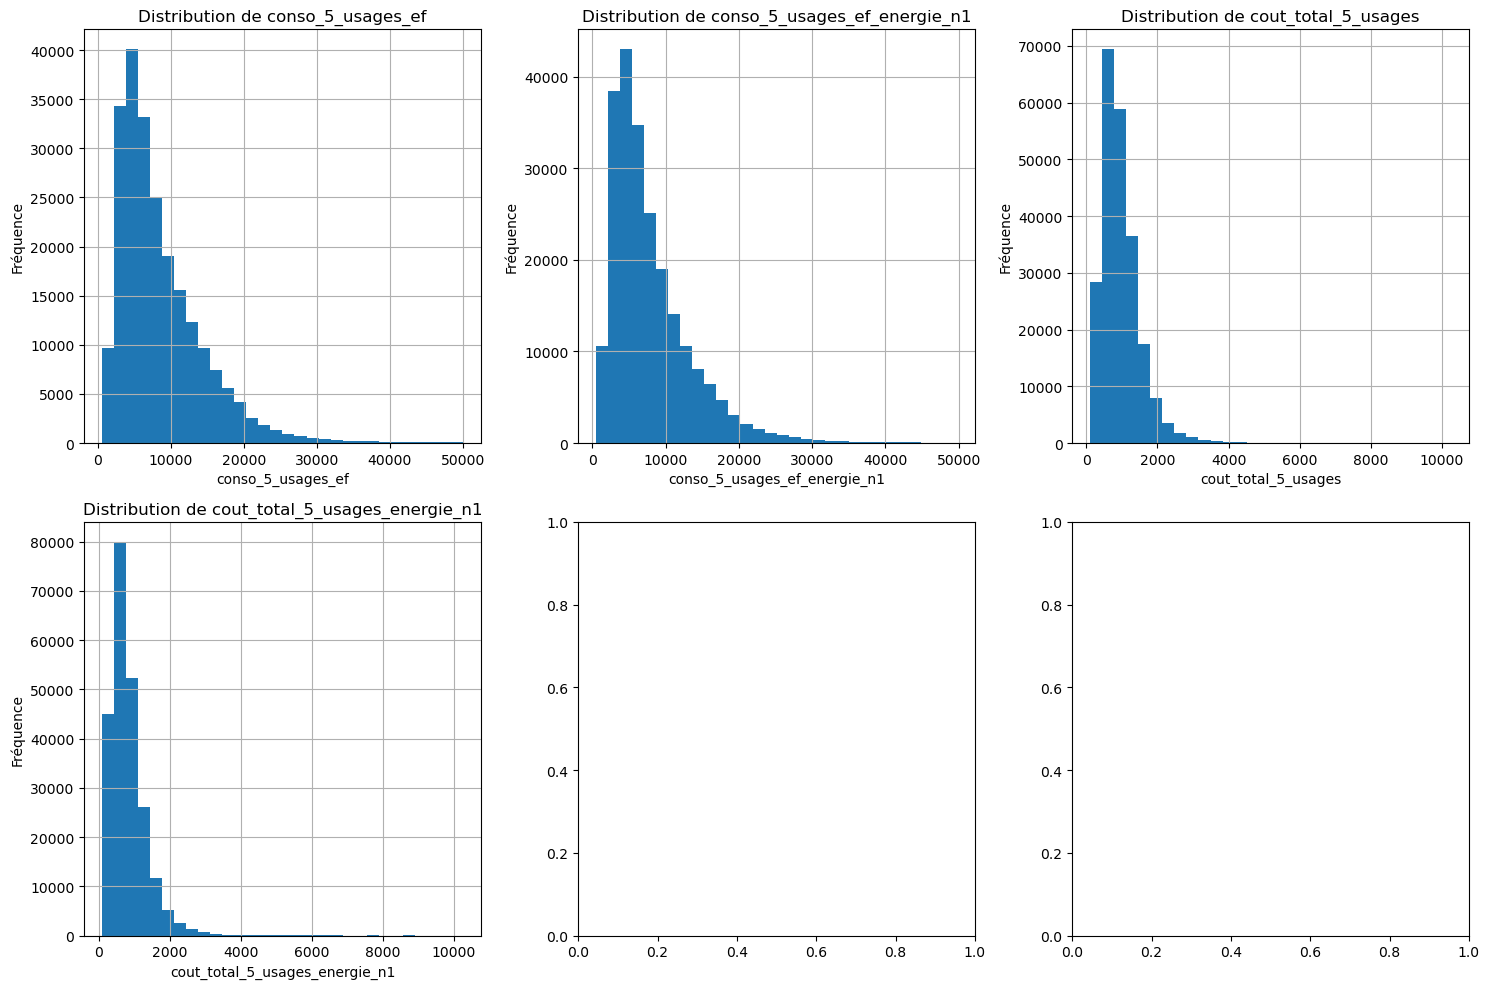

In [54]:
# Statistiques descriptives
print("Statistiques des variables quantitatives:")
print(df_Variables[variables_quantitatives].describe())

# Visualisation des distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(variables_quantitatives[:6]):  # Premières 6 variables
    df_Variables[col].hist(bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

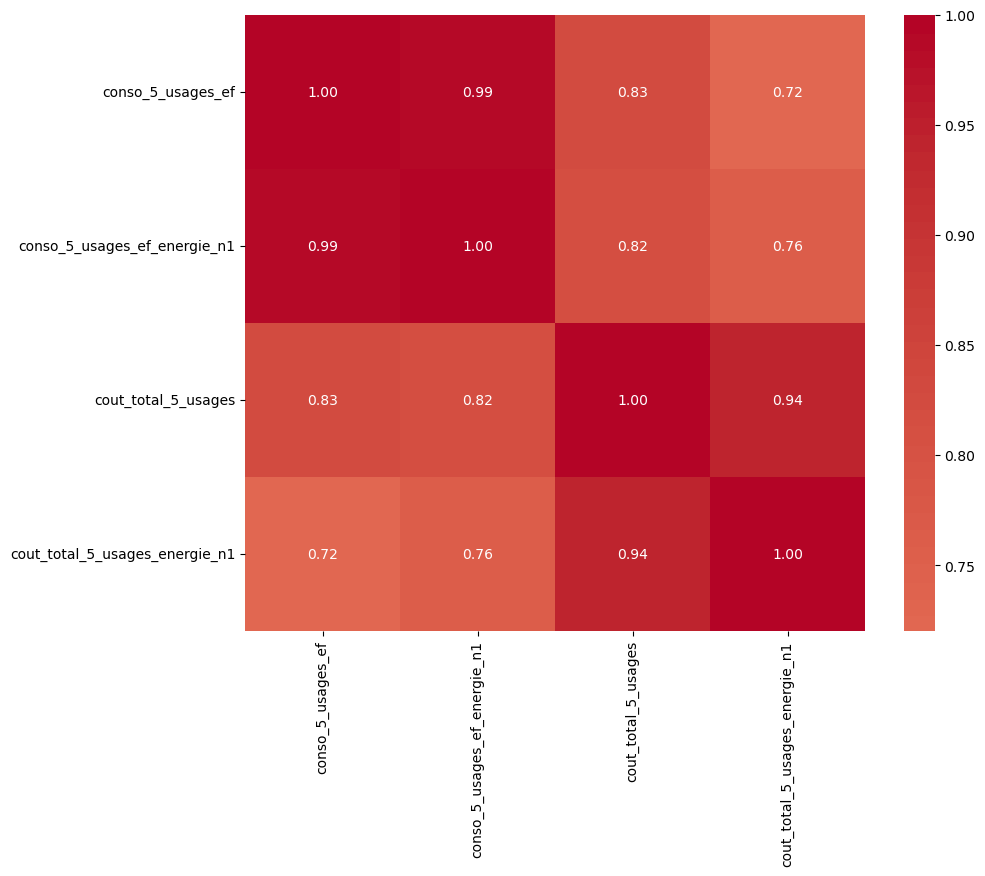

In [55]:
corr = df_Variables[variables_quantitatives].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.show()

In [56]:
df_Variables.to_csv('donnees_ml_preparees.csv', index=False)

In [57]:
print(df_Variables.columns.tolist())
print(df_Variables.shape)


['conso_5_usages_ef', 'conso_5_usages_ef_energie_n1', 'cout_total_5_usages', 'hauteur_sous_plafond', 'qualite_isolation_murs', 'type_batiment', 'cout_total_5_usages_energie_n1', 'surface_habitable_logement', 'etiquette_dpe', 'periode_construction', 'latitude', 'longitude', 'nombre_appartement_cat', 'type_energie_principale_chauffage_Bois et biomasse', 'type_energie_principale_chauffage_Charbon', 'type_energie_principale_chauffage_Fioul', 'type_energie_principale_chauffage_Gaz (GPL/Propane/Butane)', 'type_energie_principale_chauffage_Gaz naturel', 'type_energie_principale_chauffage_Réseau de chauffage urbain', 'type_energie_principale_chauffage_Électricité', 'type_energie_n1_Bois et biomasse', 'type_energie_n1_Charbon', 'type_energie_n1_Fioul', 'type_energie_n1_Gaz (GPL/Propane/Butane)', 'type_energie_n1_Gaz naturel', 'type_energie_n1_Réseau de chauffage urbain', 'type_energie_n1_Électricité', 'logement_ancien', 'logement_neuf']
(226247, 29)
